<a href="https://colab.research.google.com/github/JaimRM/QuantitativeFinance/blob/main/K_nearest_neighbors_LSTM_XGBoost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
pip install tensorflow xgboost scikit-learn yfinance pandas numpy

/tmp/ipykernel_23637/2043075809.py:17: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw_data = yf.download("^SPX", start="2018-01-01", end="2026-06-01")
[*********************100%***********************]  1 of 1 completed

Descargando datos del S&P 500...
Entrenando k-NN...
Entrenando XGBoost...
Preparando datos en 3D para LSTM...
Entrenando LSTM...



/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step

Exactitud k-NN: 52.81%
Exactitud XGBoost: 55.50%
Exactitud LSTM: 56.97%
--> EXACTITUD DEL ENSAMBLE HÍBRIDO: 56.23%


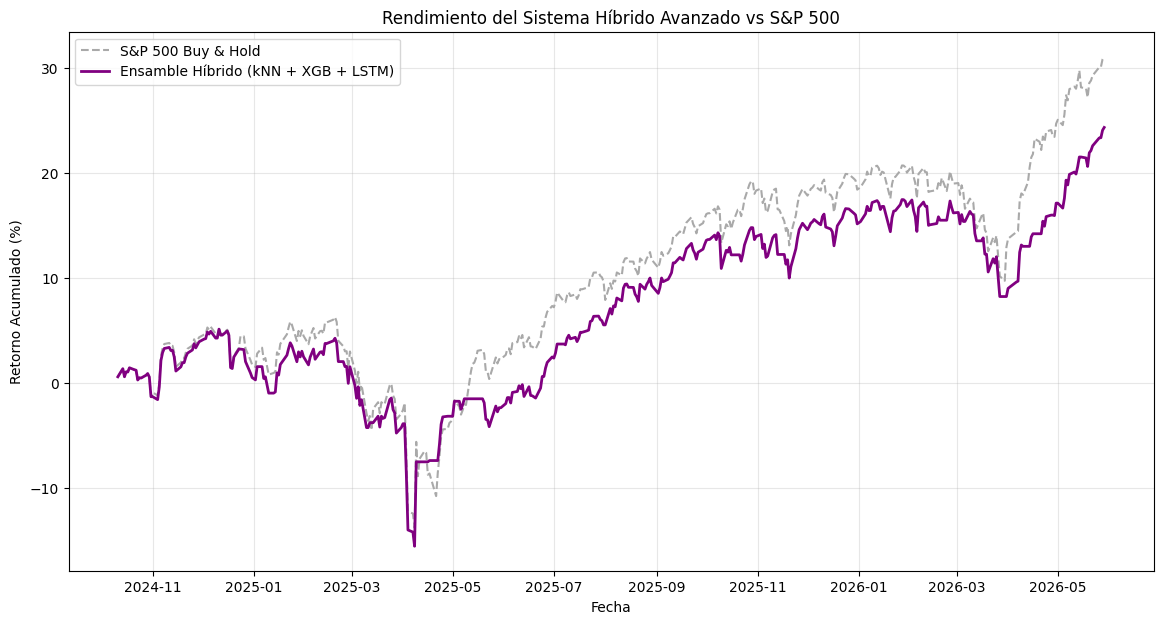

In [8]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import accuracy_score

# ==========================================
# 1. DESCARGA Y PREPARACIÓN DE DATOS (S&P 500)
# ==========================================
print("Descargando datos del S&P 500...")
# Descargamos los datos
raw_data = yf.download("^SPX", start="2018-01-01", end="2026-06-01")

# SOLUCIÓN AL KEYERROR: Forzamos a que las columnas sean nombres simples
data = raw_data.copy()
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)
else:
    data.columns = [str(col) for col in data.columns]

# --- Features para XGBoost y k-NN ---
data['Return_2d'] = data['Close'].pct_change(2)
data['Return_5d'] = data['Close'].pct_change(5)
data['Volatility_10d'] = data['Close'].pct_change().rolling(10).std()
data['MA_20'] = data['Close'] / data['Close'].rolling(20).mean()

# --- Target (Dirección de Mañana) ---
data['Target'] = np.where(data['Close'].shift(-1) > data['Close'], 1, 0)
data.dropna(inplace=True)

features_tabular = ['Return_2d', 'Return_5d', 'Volatility_10d', 'MA_20']


# ==========================================
# 2. DIVISION CRONOLÓGICA (Evita Look-ahead Bias)
# ==========================================
split = int(len(data) * 0.8)
train_df = data.iloc[:split].copy()
test_df = data.iloc[split:].copy()

# Normalización estricta (El escalador solo aprende del pasado/entrenamiento)
scaler = StandardScaler()
X_train_tab = scaler.fit_transform(train_df[features_tabular])
X_test_tab = scaler.transform(test_df[features_tabular])

y_train = train_df['Target'].values
y_test = test_df['Target'].values

# ==========================================
# 3. MODELO 1: K-Nearest Neighbors (k-NN)
# ==========================================
print("Entrenando k-NN...")
knn = KNeighborsClassifier(n_neighbors=7, metric='manhattan')
knn.fit(X_train_tab, y_train)
pred_knn = knn.predict(X_test_tab)

# ==========================================
# 4. MODELO 2: XGBoost
# ==========================================
print("Entrenando XGBoost...")
xgb = XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.05, random_state=42, eval_metric='logloss')
xgb.fit(X_train_tab, y_train)
pred_xgb = xgb.predict(X_test_tab)

# ==========================================
# 5. MODELO 3: LSTM (Deep Learning) - CORREGIDO
# ==========================================
print("Preparando datos en 3D para LSTM...")
scaler_lstm = StandardScaler()
scaled_close_train = scaler_lstm.fit_transform(train_df[['Close']])
scaled_close_test = scaler_lstm.transform(test_df[['Close']])

def create_sequences(data_array, target_array, time_steps=10):
    Xs, ys = [], []
    for i in range(len(data_array) - time_steps):
        Xs.append(data_array[i:(i + time_steps)])
        ys.append(target_array[i + time_steps])
    return np.array(Xs), np.array(ys)

time_steps = 10
X_train_lstm, y_train_lstm = create_sequences(scaled_close_train, y_train, time_steps)
X_test_lstm, y_test_lstm = create_sequences(scaled_close_test, y_test, time_steps)

print("Entrenando LSTM...")
lstm = Sequential([
    LSTM(50, return_sequences=False, input_shape=(time_steps, 1)),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Entrenamiento rápido para evitar sobreajuste
lstm.fit(X_train_lstm, y_train_lstm, epochs=10, batch_size=32, verbose=0)

# Predicción probabilística convertida a binaria (0 o 1)
pred_lstm_prob = lstm.predict(X_test_lstm)
pred_lstm = np.where(pred_lstm_prob > 0.5, 1, 0).flatten()

# ==========================================
# 6. ENSAMBLE POR VOTACIÓN HÍBRIDA
# ==========================================
# Alineamos las longitudes debido al desfase de ventanas (time_steps) de la LSTM
ajuste = time_steps
y_test_final = y_test_lstm
pred_knn_final = pred_knn[ajuste:]
pred_xgb_final = pred_xgb[ajuste:]

# Sumamos los votos. Si la suma es >= 2, la mayoría gana (1). Si no, (0).
votos_totales = pred_knn_final + pred_xgb_final + pred_lstm
pred_ensemble = np.where(votos_totales >= 2, 1, 0)

print(f"\nExactitud k-NN: {accuracy_score(y_test_final, pred_knn_final):.2%}")
print(f"Exactitud XGBoost: {accuracy_score(y_test_final, pred_xgb_final):.2%}")
print(f"Exactitud LSTM: {accuracy_score(y_test_final, pred_lstm):.2%}")
print(f"--> EXACTITUD DEL ENSAMBLE HÍBRIDO: {accuracy_score(y_test_final, pred_ensemble):.2%}")

# ==========================================
# 7. BACKTESTING DE LA ESTRATEGIA COMBINADA
# ==========================================
backtest = pd.DataFrame(index=test_df.index[ajuste:])
backtest['Market_Return'] = test_df['Close'].iloc[ajuste:].pct_change()
backtest['Signal'] = pred_ensemble

# La señal de hoy aplica al retorno de mañana
backtest['Strategy_Return'] = backtest['Market_Return'] * backtest['Signal'].shift(1)
backtest.dropna(inplace=True)

backtest['Cum_Market'] = (1 + backtest['Market_Return']).cumprod() - 1
backtest['Cum_Strategy'] = (1 + backtest['Strategy_Return']).cumprod() - 1

# ==========================================
# 8. GRÁFICA DE RENTABILIDAD
# ==========================================
plt.figure(figsize=(14, 7))
plt.plot(backtest['Cum_Market'] * 100, label='S&P 500 Buy & Hold', color='darkgray', linestyle='--')
plt.plot(backtest['Cum_Strategy'] * 100, label='Ensamble Híbrido (kNN + XGB + LSTM)', color='purple', linewidth=2)
plt.title('Rendimiento del Sistema Híbrido Avanzado vs S&P 500')
plt.xlabel('Fecha')
plt.ylabel('Retorno Acumulado (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


/tmp/ipykernel_23637/88487399.py:17: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw_data = yf.download("^SPX", start="2018-01-01", end="2026-06-01")
[*********************100%***********************]  1 of 1 completed

Descargando datos del S&P 500...
Entrenando k-NN...
Entrenando XGBoost...
Preparando datos en 3D para LSTM...
Entrenando LSTM...



/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

Exactitud k-NN: 52.81%
Exactitud XGBoost: 55.50%
Exactitud LSTM: 56.97%
--> EXACTITUD DEL ENSAMBLE HÍBRIDO: 56.23%

=== RENDIMIENTO FINAL CON VENTAS EN CORTO ===
Retorno S&P 500 Buy & Hold: 31.14%
Retorno Estrategia Híbrida (Long/Short): 16.98%


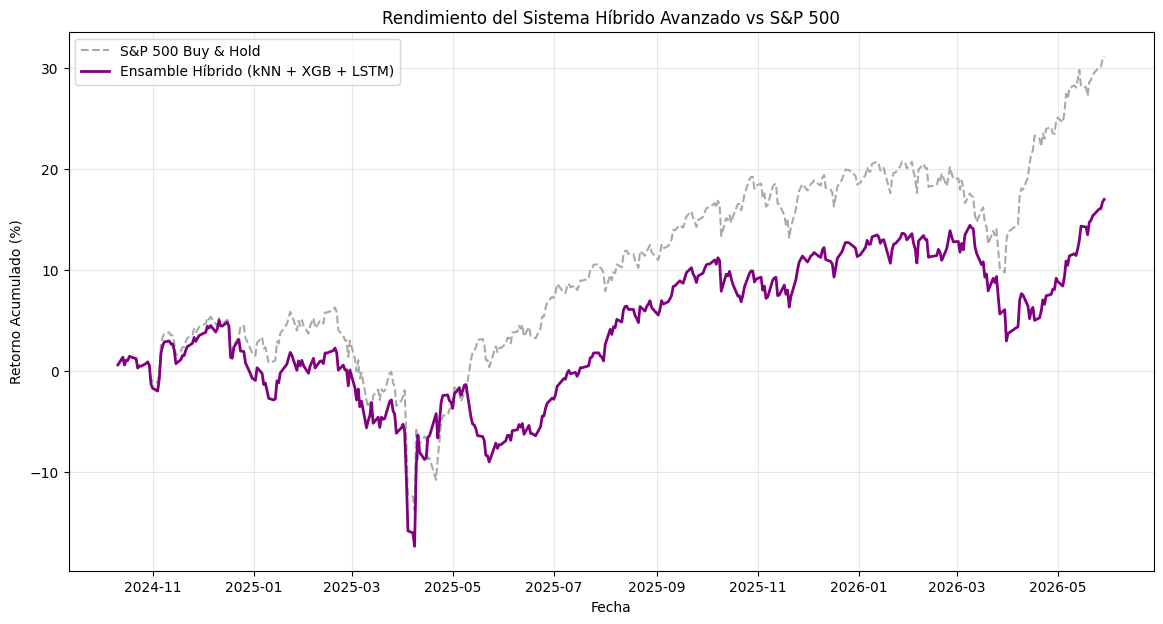

In [9]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import accuracy_score

# ==========================================
# 1. DESCARGA Y PREPARACIÓN DE DATOS (S&P 500)
# ==========================================
print("Descargando datos del S&P 500...")
# Descargamos los datos
raw_data = yf.download("^SPX", start="2018-01-01", end="2026-06-01")

# SOLUCIÓN AL KEYERROR: Forzamos a que las columnas sean nombres simples
data = raw_data.copy()
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)
else:
    data.columns = [str(col) for col in data.columns]

# --- Features para XGBoost y k-NN ---
data['Return_2d'] = data['Close'].pct_change(2)
data['Return_5d'] = data['Close'].pct_change(5)
data['Volatility_10d'] = data['Close'].pct_change().rolling(10).std()
data['MA_20'] = data['Close'] / data['Close'].rolling(20).mean()

# --- Target (Dirección de Mañana) ---
data['Target'] = np.where(data['Close'].shift(-1) > data['Close'], 1, 0)
data.dropna(inplace=True)

features_tabular = ['Return_2d', 'Return_5d', 'Volatility_10d', 'MA_20']


# ==========================================
# 2. DIVISION CRONOLÓGICA (Evita Look-ahead Bias)
# ==========================================
split = int(len(data) * 0.8)
train_df = data.iloc[:split].copy()
test_df = data.iloc[split:].copy()

# Normalización estricta (El escalador solo aprende del pasado/entrenamiento)
scaler = StandardScaler()
X_train_tab = scaler.fit_transform(train_df[features_tabular])
X_test_tab = scaler.transform(test_df[features_tabular])

y_train = train_df['Target'].values
y_test = test_df['Target'].values

# ==========================================
# 3. MODELO 1: K-Nearest Neighbors (k-NN)
# ==========================================
print("Entrenando k-NN...")
knn = KNeighborsClassifier(n_neighbors=7, metric='manhattan')
knn.fit(X_train_tab, y_train)
pred_knn = knn.predict(X_test_tab)

# ==========================================
# 4. MODELO 2: XGBoost
# ==========================================
print("Entrenando XGBoost...")
xgb = XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.05, random_state=42, eval_metric='logloss')
xgb.fit(X_train_tab, y_train)
pred_xgb = xgb.predict(X_test_tab)

# ==========================================
# 5. MODELO 3: LSTM (Deep Learning) - CORREGIDO
# ==========================================
print("Preparando datos en 3D para LSTM...")
scaler_lstm = StandardScaler()
scaled_close_train = scaler_lstm.fit_transform(train_df[['Close']])
scaled_close_test = scaler_lstm.transform(test_df[['Close']])

def create_sequences(data_array, target_array, time_steps=10):
    Xs, ys = [], []
    for i in range(len(data_array) - time_steps):
        Xs.append(data_array[i:(i + time_steps)])
        ys.append(target_array[i + time_steps])
    return np.array(Xs), np.array(ys)

time_steps = 10
X_train_lstm, y_train_lstm = create_sequences(scaled_close_train, y_train, time_steps)
X_test_lstm, y_test_lstm = create_sequences(scaled_close_test, y_test, time_steps)

print("Entrenando LSTM...")
lstm = Sequential([
    LSTM(50, return_sequences=False, input_shape=(time_steps, 1)),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Entrenamiento rápido para evitar sobreajuste
lstm.fit(X_train_lstm, y_train_lstm, epochs=10, batch_size=32, verbose=0)

# Predicción probabilística convertida a binaria (0 o 1)
pred_lstm_prob = lstm.predict(X_test_lstm)
pred_lstm = np.where(pred_lstm_prob > 0.5, 1, 0).flatten()

# ==========================================
# 6. ENSAMBLE POR VOTACIÓN HÍBRIDA
# ==========================================
# Alineamos las longitudes debido al desfase de ventanas (time_steps) de la LSTM
ajuste = time_steps
y_test_final = y_test_lstm
pred_knn_final = pred_knn[ajuste:]
pred_xgb_final = pred_xgb[ajuste:]

# Sumamos los votos. Si la suma es >= 2, la mayoría gana (1). Si no, (0).
votos_totales = pred_knn_final + pred_xgb_final + pred_lstm
pred_ensemble = np.where(votos_totales >= 2, 1, 0)

print(f"\nExactitud k-NN: {accuracy_score(y_test_final, pred_knn_final):.2%}")
print(f"Exactitud XGBoost: {accuracy_score(y_test_final, pred_xgb_final):.2%}")
print(f"Exactitud LSTM: {accuracy_score(y_test_final, pred_lstm):.2%}")
print(f"--> EXACTITUD DEL ENSAMBLE HÍBRIDO: {accuracy_score(y_test_final, pred_ensemble):.2%}")

# ==========================================
# 7. BACKTESTING CON POSICIONES CORTAS (SHORTS)
# ==========================================
backtest = pd.DataFrame(index=test_df.index[ajuste:])
backtest['Market_Return'] = test_df['Close'].iloc[ajuste:].pct_change()

# LÓGICA DE CORTOS: Si la señal es 1, mantenemos 1. Si la señal es 0, cambiamos a -1 (Short)
backtest['Signal'] = np.where(pred_ensemble == 1, 1, -1)

# La señal generada hoy se ejecuta y aplica para el retorno de mañana
backtest['Strategy_Return'] = backtest['Market_Return'] * backtest['Signal'].shift(1)
backtest.dropna(inplace=True)

# Rendimientos compuestos acumulados
backtest['Cum_Market'] = (1 + backtest['Market_Return']).cumprod() - 1
backtest['Cum_Strategy'] = (1 + backtest['Strategy_Return']).cumprod() - 1

# Métricas de control
final_market = backtest['Cum_Market'].iloc[-1]
final_strategy = backtest['Cum_Strategy'].iloc[-1]

print("\n=== RENDIMIENTO FINAL CON VENTAS EN CORTO ===")
print(f"Retorno S&P 500 Buy & Hold: {final_market:.2%}")
print(f"Retorno Estrategia Híbrida (Long/Short): {final_strategy:.2%}")

# ==========================================
# 8. GRÁFICA DE RENTABILIDAD
# ==========================================
plt.figure(figsize=(14, 7))
plt.plot(backtest['Cum_Market'] * 100, label='S&P 500 Buy & Hold', color='darkgray', linestyle='--')
plt.plot(backtest['Cum_Strategy'] * 100, label='Ensamble Híbrido (kNN + XGB + LSTM)', color='purple', linewidth=2)
plt.title('Rendimiento del Sistema Híbrido Avanzado vs S&P 500')
plt.xlabel('Fecha')
plt.ylabel('Retorno Acumulado (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
